In [2]:
# 고객 이탈에 여부 분류 모델
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
# 데이터 읽기
import pandas as pd
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. 데이터 기본정보 확인
df.info()
# TotalCharges      7043 non-null   object 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.select_dtypes(include=['object'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [5]:
bad_values = []
for val in df['TotalCharges']:
    try:
        float(val)
    except Exception as e:
        bad_values.append(val)  # 에러 발생 값 저장
print(bad_values)
# 빈칸으로 되어있다.

[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']


In [6]:
# 결측치 NaN으로 변환하기
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [7]:
df.info()
# TotalCharges      7043 non-null   object 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# 범주형 데이터를 수치형 데이터로 변환하기
df['Churn'] = df.Churn.map({'Yes':1,'No':0})
print(df.Churn)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# 클래스 불균형 점검 및 불균형 맞춰보기
# 학습용 데이터 임의 지정하여 진행 : MonthlyCharges,  TotalCharges -> 실제에서는 데이터 지정과정중에 고민하는 시간이 필요

In [11]:
# 고객이 해지할지 안 할지를 예측하는 이진 분류(Binary Classification) 모델을 생성하기

#### baseline 데이터 및 모델 생성

In [12]:
# 피처 선택
base_df = df.select_dtypes(include={'int','float'}).copy()

# 결측치 처리
base_df = base_df.dropna()

X = base_df.drop(columns=['Churn']).to_numpy()
y = base_df.Churn

# 판다스 보다, 넘파이 형태가 처리속도가 조금 더 빠르다

# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 모델 생성
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

# 모델 학습
knn.fit(x_train_scaled,y_train)

# 모델 평가
from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.82      0.88      0.84      1033
           1       0.57      0.45      0.51       374

    accuracy                           0.76      1407
   macro avg       0.69      0.66      0.67      1407
weighted avg       0.75      0.76      0.75      1407



In [13]:
# 불균형 확인
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [14]:
y.value_counts(normalize=True)  # 불균형 비율 확인

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

### 2. 주요 특성 시각화

In [23]:
# 고객 이탈에 여부 분류 모델
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
# 데이터 읽기
import pandas as pd
df = pd.read_csv(url)
df = df.drop(columns=['customerID'])
df.describe(include=['object'])

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### 데이터 누수 Data Leakage
학습데이터에 정답데이터(컬럼) 포함

In [16]:
import seaborn as sns
# 성별에 따른 이탈률
# sns.countplot(data=df,x='PhoneService',hue='Churn')
# 차이를 보이는 Partner	Dependents	PhoneService 컬럼을 onehot으로 변경해서 학습에 적용
new_df =  df.copy()
new_df = new_df.dropna()

X = new_df.drop(columns=['Churn'])
new_df['Churn'] = new_df.Churn.map({'Yes':1,'No':0})
y = new_df.Churn.to_numpy()

new_df['Partner']=new_df.Partner.map({'Yes':1, 'No':0})
new_df['Dependents']=new_df.Dependents.map({'Yes':1, 'No':0})
new_df['PhoneService']=new_df.PhoneService.map({'Yes':1, 'No':0})

new_df = pd.concat([new_df,pd.get_dummies(new_df.Partner).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.Dependents).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.PhoneService).astype(int)],axis=1)

new_df = new_df.drop(columns=['Partner','Dependents','PhoneService'])
new_df.head()

# 학습가능한 수치데이터
train_df = new_df.select_dtypes(include=['int','float'])
X = train_df.to_numpy()
# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2, random_state=42)
# 정규화
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
x_train_scaled = s.fit_transform(x_train);  x_test_scaled = s.fit_transform(x_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)

from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [17]:
import seaborn as sns
# 성별에 따른 이탈률
# sns.countplot(data=df,x='PhoneService',hue='Churn')
# 차이를 보이는 Partner	Dependents	PhoneService 컬럼을 onehot으로 변경해서 학습에 적용
new_df =  df.copy()
new_df = new_df.dropna()
new_df['Churn'] = new_df.Churn.map({'Yes':1,'No':0})
new_df['Partner']=new_df.Partner.map({'Yes':1, 'No':0})
new_df['Dependents']=new_df.Dependents.map({'Yes':1, 'No':0})
new_df['PhoneService']=new_df.PhoneService.map({'Yes':1, 'No':0})

new_df = pd.concat([new_df,pd.get_dummies(new_df.Partner).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.Dependents).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.PhoneService).astype(int)],axis=1)

new_df = new_df.drop(columns=['Partner','Dependents','PhoneService'])

# 학습가능한 수치데이터
train_df = new_df.select_dtypes(include=['int','float'])
X = train_df.drop(columns=['Churn']).to_numpy()
y = train_df.Churn.to_numpy()

# 클래스 불균형 해결
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X,y = smote.fit_resample(X,y)
# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2, random_state=42)
# 정규화
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
x_train_scaled = s.fit_transform(x_train);  x_test_scaled = s.transform(x_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)

from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1035
           1       0.80      0.81      0.80      1035

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070



### 새로운 피처 탐색

In [18]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df = df.dropna()

In [19]:
df.select_dtypes(exclude=['object']).corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [20]:
import seaborn as sns
# 성별에 따른 이탈률
# sns.countplot(data=df,x='PhoneService',hue='Churn')
# 차이를 보이는 Partner	Dependents	PhoneService 컬럼을 onehot으로 변경해서 학습에 적용
new_df =  df.copy()
new_df['TotalCharges'] =  pd.to_numeric(new_df.TotalCharges, errors='coerce')
new_df = new_df.dropna()
new_df['Churn'] = new_df.Churn.map({'Yes':1,'No':0})
# new_df['Partner']=new_df.Partner.map({'Yes':1, 'No':0})
# new_df['Dependents']=new_df.Dependents.map({'Yes':1, 'No':0})
# new_df['PhoneService']=new_df.PhoneService.map({'Yes':1, 'No':0})

new_df = pd.concat([new_df,pd.get_dummies(new_df.Partner).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.Dependents).astype(int)],axis=1)
new_df = pd.concat([new_df,pd.get_dummies(new_df.PhoneService).astype(int)],axis=1)

new_df = new_df.drop(columns=['Partner','Dependents','PhoneService','TotalCharges'])

# 학습가능한 수치데이터
train_df = new_df.select_dtypes(include=['int','float'])
X = train_df.drop(columns=['Churn']).to_numpy()
y = train_df.Churn.to_numpy()

# 클래스 불균형 해결
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X,y = smote.fit_resample(X,y)
# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2, random_state=42)
# 정규화
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
x_train_scaled = s.fit_transform(x_train);  x_test_scaled = s.transform(x_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)

from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.79      0.81      0.80      1033

    accuracy                           0.80      2066
   macro avg       0.80      0.80      0.80      2066
weighted avg       0.80      0.80      0.80      2066



In [21]:

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<Axes: xlabel='tenure', ylabel='Count'>

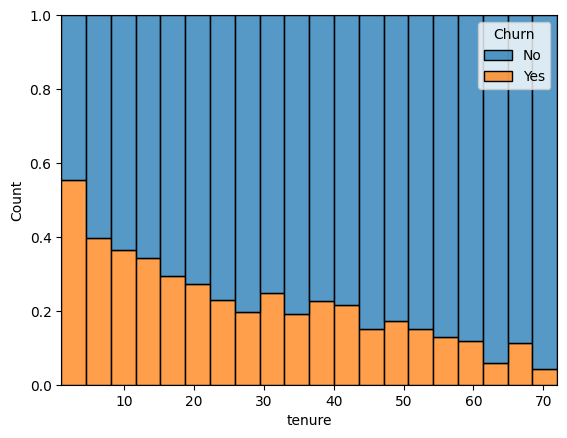

In [22]:
# tenure 에 따른 이탈률
sns.histplot(data=df, x='tenure', hue='Churn',multiple='fill',bins=20)

<Axes: xlabel='Contract', ylabel='Count'>

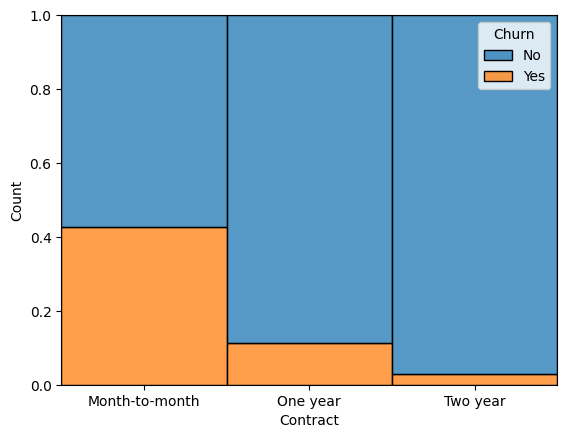

In [23]:
# Contract 에 따른 이탈률
sns.histplot(data=df, x='Contract', hue='Churn',multiple='fill',bins=20)

In [2]:
# 고객 이탈에 여부 분류 모델
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
# 데이터 읽기
import pandas as pd
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# baseline에서 상관관계로 TotalCharge 변수 제거한 데이터에
# tenure , Contract 를 범주형 데이터를 변환하고 onehot으로 변경

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015683        0.219874      0.102411
tenure               0.015683  1.000000        0.246862      0.825880
MonthlyCharges       0.219874  0.246862        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


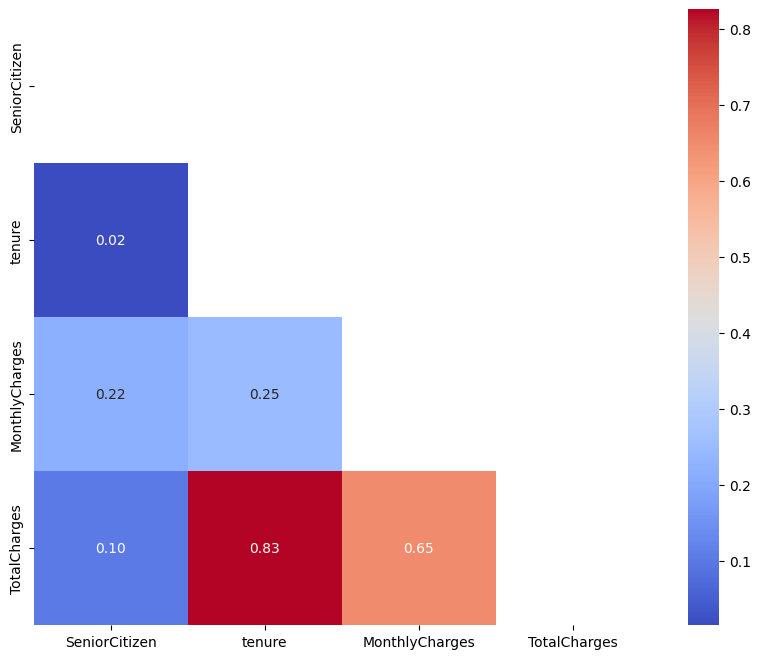

In [6]:
# 학생 풀이
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터 베이스 복사
new_df2 = df.copy()

# 결측치 NaN 변환
new_df2['TotalCharges'] = pd.to_numeric(new_df2['TotalCharges'],errors='coerce')

# 결측치 제거
new_df2 = new_df2.dropna()

# 상관계수 계산
corr = new_df2.corr(numeric_only=True)
print(corr)

# 마스크 생성( 하단 부분이 나오게 설정)
mask = np.triu(np.ones_like(corr, dtype=bool)) # ^

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', 
            annot=True, fmt=".2f", cbar=True, square=True)
plt.show()

# Totalcharge 와 tenure 가 유사도가 높고, 제시된 문제에 Totalcharge를 삭제하는 것을 요청

# Totalcharge 행 삭제
new_df2.drop('TotalCharges', axis=1, inplace=True) # axis
                                                   # inplace

In [ ]:
# tenure , Contract 를 범주형 데이터를 변환하고 onehot으로 변경

# 원-핫 인코딩된 열끼리 상관계수는 “이 범주가 나타나는지 여부” 간의 상관 정도를 보는 거라 계산에 안들어간다.
# 그래서 상관계수 삭제 이전에 하지않아도 괜찮다.

In [7]:
# 범주형 데이터 onehot인코딩 하기(1)
# tenure : 가입한 개월 수

# 가입한 개월수를 왜 핫 인코딩하느걸까.. 이건수치형데이터로하는게 낫지않나?
# 장점: 모델이 tenure가 증가할수록 churn 가능성이 감소하는 선형적 관계를 학습 가능

In [8]:
# 범주형 데이터 onehot인코딩 하기(2)
# Contract : 계약 종류

# Month-to-month: 매달 갱신되는 계약
# One year: 1년 단위 계약
# Two year: 2년 단위 계약

In [ ]:
# 범주형 데이터를 변환, onehot으로 변경하기
# np.histogram 으로 3개의 bin으로 나누는 경계 값의 리스트 구하기
count, bin_dividers = np.histogram(df['horsepower'], bins=3)

# 3개의 bin에 이름 지정
bin_names = ['저출력', '보통출력', '고출력']

# pd.cut 으로 각 데이터를 3개의 bin에 할당
df['hp_bin'] = pd.cut(x=df['horsepower'],     # 데이터 배열
                      bins=bin_dividers,      # 경계 값 리스트
                      labels=bin_names,       # bin 이름
                      include_lowest=True)    # 첫 경계값 포함

# sklern 라이브러리 불러오기
from sklearn import preprocessing    

# 전처리를 위한 encoder 객체 만들기
label_encoder = preprocessing.LabelEncoder()       # label encoder 생성
onehot_encoder = preprocessing.OneHotEncoder()     # one hot encoder 생성

# label encoder로 문자열 범주를 숫자형 범주로 변환
onehot_labeled = label_encoder.fit_transform(df['hp_bin'].head(15))  
print(onehot_labeled)
print(type(onehot_labeled))

# 2차원 행렬로 형태 변경
onehot_reshaped = onehot_labeled.reshape(len(onehot_labeled), 1) 
print(onehot_reshaped)
print(type(onehot_reshaped))

# 희소행렬로 변환
onehot_fitted = onehot_encoder.fit_transform(onehot_reshaped)
print(onehot_fitted)
print(type(onehot_fitted))